# 02. Analisis Exploratorio de Datos (EDA)

Exploracion de los datos recogidos de Instagram, TikTok y Trustpilot para Lululemon.

**Colores:** Instagram (rosa), TikTok (negro), Trustpilot (verde)

**Secciones:**
1. Carga y preparacion
2. Distribucion temporal
3. Distribucion por region (US vs Europa)
4. Deep dive: idiomas en Europa
5. Volumetria: entries por region y fuente

In [46]:
import sys
sys.path.insert(0, "../../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from plotting import setup_style, save_fig, PLATFORM_COLORS
setup_style()

C_IG = PLATFORM_COLORS["instagram"]
C_TK = PLATFORM_COLORS["tiktok"]
C_TP = PLATFORM_COLORS["trustpilot"]

DATA = "../../datos/clean"

tp = pd.read_csv(f"{DATA}/trustpilot_all.csv", parse_dates=["published_date"])
ig = pd.read_csv(f"{DATA}/ig_publicaciones.csv", parse_dates=["timestamp"])
ig_com = pd.read_csv(f"{DATA}/ig_comentarios.csv", parse_dates=["timestamp"])
tk = pd.read_csv(f"{DATA}/tiktok_videos.csv", parse_dates=["uploaded_at"])
tk_com = pd.read_csv(f"{DATA}/tiktok_comentarios.csv", parse_dates=["timestamp"])

tp_lulu = tp[tp["brand"] == "Lululemon"].copy()

# Clasificar US vs Europa
EU_COUNTRIES = ["GB", "ES", "DE", "FR", "NL", "IE", "IT", "FI", "RO", "AT", "BE", "PT", "SE", "DK", "NO", "CH"]
US_COUNTRIES = ["US", "CA"]

tp_lulu["zone"] = tp_lulu["country"].apply(lambda x: "US" if x in US_COUNTRIES else ("Europa" if x in EU_COUNTRIES else "Otro"))
ig_com["zone"] = ig_com["region"].apply(lambda x: "US" if x == "US" else "Europa")
tk["zone"] = tk["region_search"].apply(lambda x: "US" if x == "US" else "Europa")
tk_com["zone"] = tk_com["region_search"].apply(lambda x: "US" if x == "US" else "Europa")

print("Datos cargados correctamente.")

Datos cargados correctamente.


## 1. Distribucion temporal

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/eda_distribucion_temporal.png


/var/folders/hw/k9dl2bvx033g270sxxkmnwlw0000gn/T/ipykernel_16740/1563723804.py:13: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  tk_monthly = tk.groupby(tk["uploaded_at"].dt.to_period("M")).size()


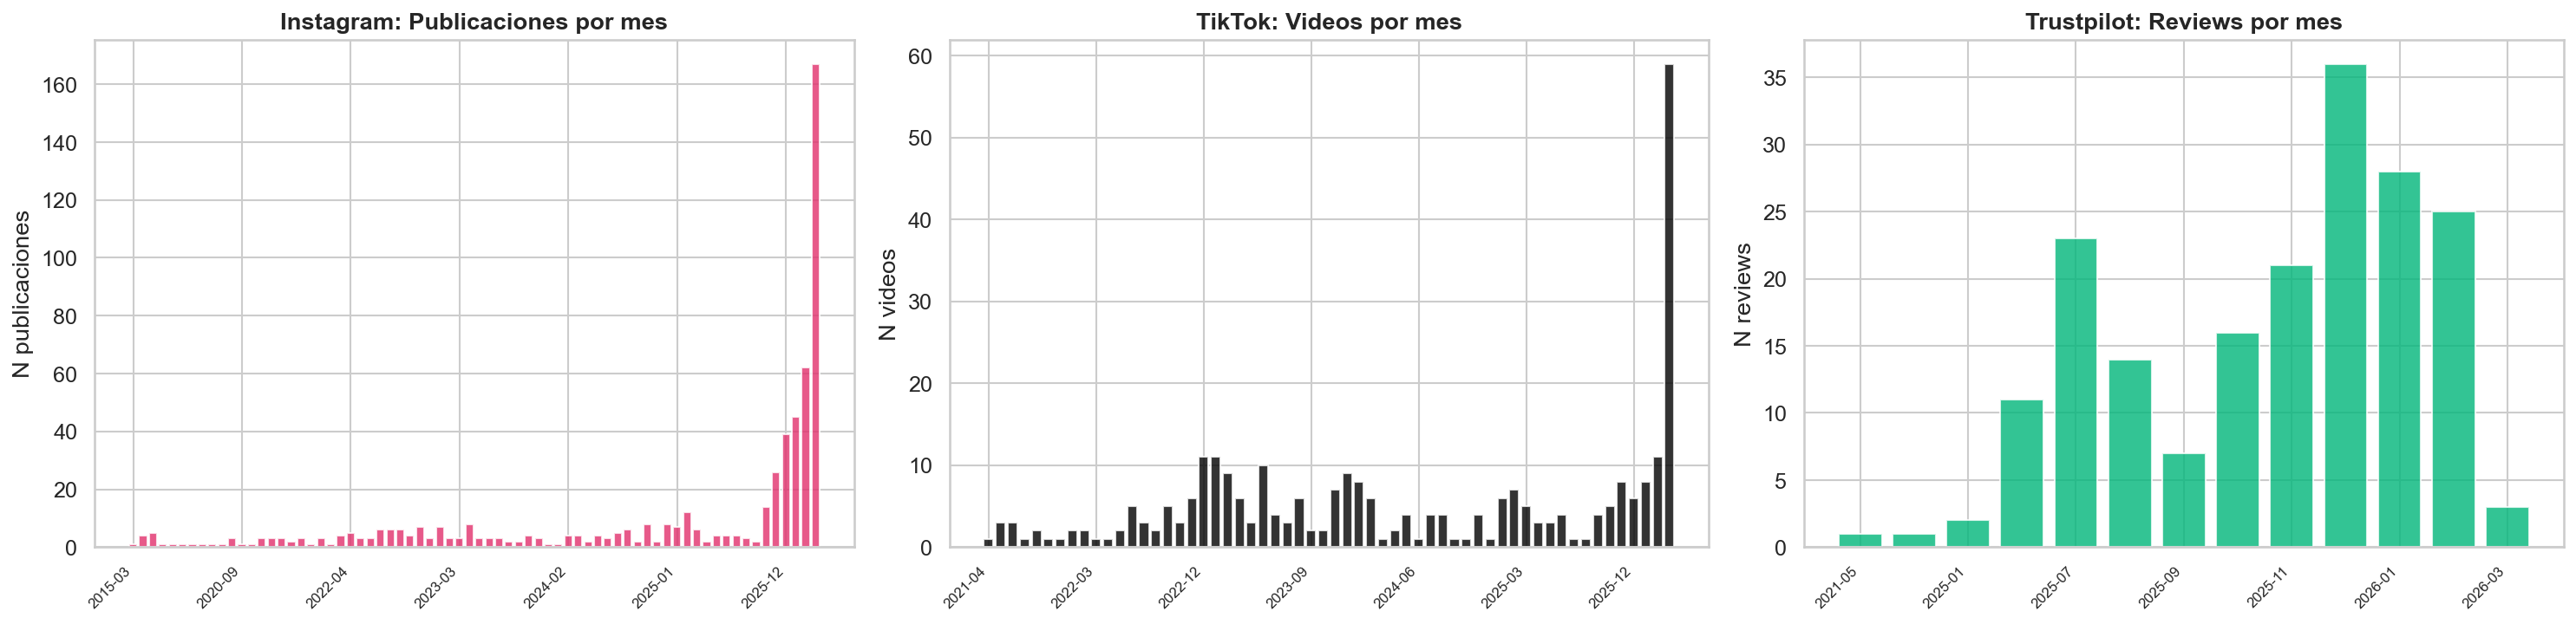

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Instagram
ig_monthly = ig.groupby(ig["timestamp"].dt.to_period("M")).size()
axes[0].bar(range(len(ig_monthly)), ig_monthly.values, color=C_IG, alpha=0.8)
axes[0].set_title("Instagram: Publicaciones por mes", fontweight="bold")
axes[0].set_ylabel("N publicaciones")
labels = ig_monthly.index.astype(str)
axes[0].set_xticks(range(0, len(labels), max(1, len(labels)//6)))
axes[0].set_xticklabels(labels[::max(1, len(labels)//6)], rotation=45, ha="right", fontsize=8)

# TikTok
tk_monthly = tk.groupby(tk["uploaded_at"].dt.to_period("M")).size()
axes[1].bar(range(len(tk_monthly)), tk_monthly.values, color=C_TK, alpha=0.8)
axes[1].set_title("TikTok: Videos por mes", fontweight="bold")
axes[1].set_ylabel("N videos")
labels = tk_monthly.index.astype(str)
axes[1].set_xticks(range(0, len(labels), max(1, len(labels)//6)))
axes[1].set_xticklabels(labels[::max(1, len(labels)//6)], rotation=45, ha="right", fontsize=8)

# Trustpilot
tp_monthly = tp_lulu.groupby(tp_lulu["published_date"].dt.to_period("M")).size()
axes[2].bar(range(len(tp_monthly)), tp_monthly.values, color=C_TP, alpha=0.8)
axes[2].set_title("Trustpilot: Reviews por mes", fontweight="bold")
axes[2].set_ylabel("N reviews")
labels = tp_monthly.index.astype(str)
axes[2].set_xticks(range(0, len(labels), max(1, len(labels)//6)))
axes[2].set_xticklabels(labels[::max(1, len(labels)//6)], rotation=45, ha="right", fontsize=8)

plt.tight_layout()
save_fig(fig, "eda_distribucion_temporal")
plt.show()

**Interpretacion:** La distribucion temporal muestra cuando se ha generado el contenido recogido. Picos en ciertos meses pueden coincidir con lanzamientos de producto, campanas de marketing o temporadas de compras. Permite identificar si los datos cubren un rango temporal suficiente y si hay periodos infrarrepresentados.

## 2. Distribucion por region (US vs Europa)

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/eda_distribucion_region.png


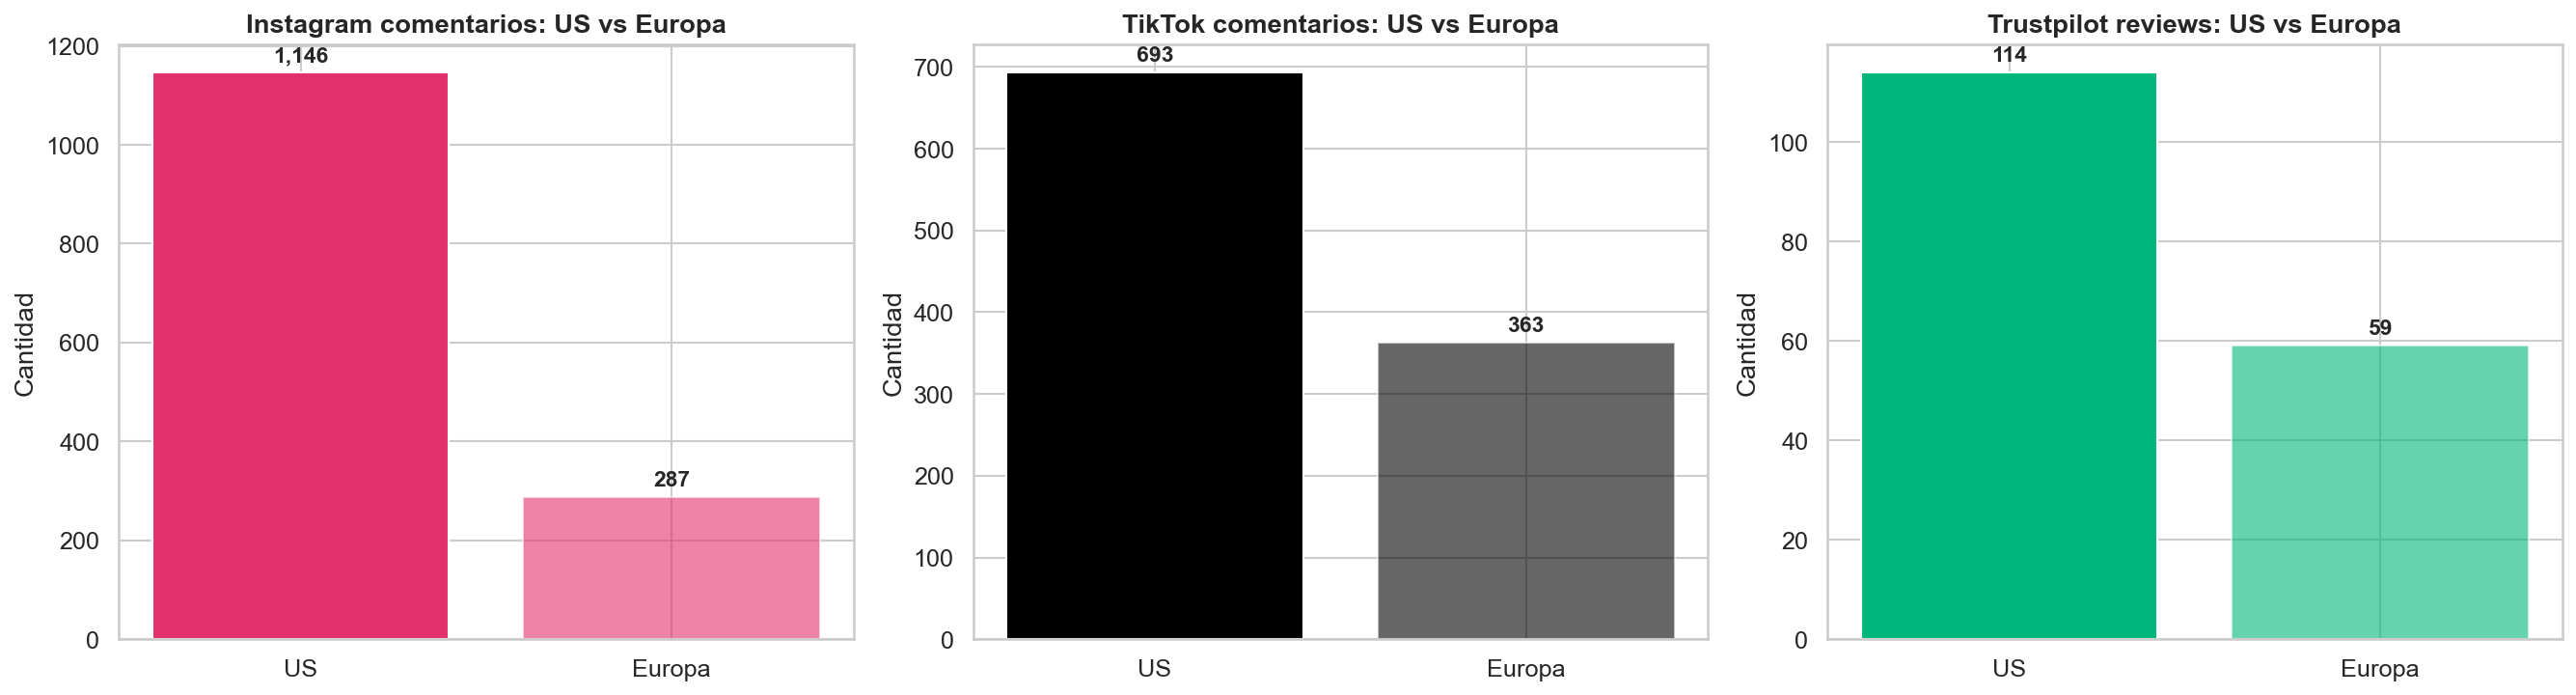

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = [
    ("Instagram comentarios", ig_com, C_IG),
    ("TikTok comentarios", tk_com, C_TK),
    ("Trustpilot reviews", tp_lulu, C_TP),
]

for ax, (name, df, color) in zip(axes, datasets):
    zone_counts = df["zone"].value_counts().reindex(["US", "Europa"]).fillna(0).astype(int)
    bars = ax.bar(zone_counts.index, zone_counts.values, color=[color, color])
    bars[1].set_alpha(0.6)
    ax.set_title(f"{name}: US vs Europa", fontweight="bold")
    ax.set_ylabel("Cantidad")
    for i, v in enumerate(zone_counts.values):
        ax.text(i, v + max(zone_counts.values)*0.02, f"{v:,}", ha="center", fontweight="bold", fontsize=11)

plt.tight_layout()
save_fig(fig, "eda_distribucion_region")
plt.show()

**Interpretacion:** El desglose US vs Europa muestra el peso relativo de cada mercado en la muestra. US domina consistentemente en las tres fuentes, reflejando el origen norteamericano de Lululemon. La proporcion Europa/US es un factor a tener en cuenta al comparar metricas entre zonas.

## 3. Deep dive: idiomas en Europa

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/eda_europa_idiomas.png


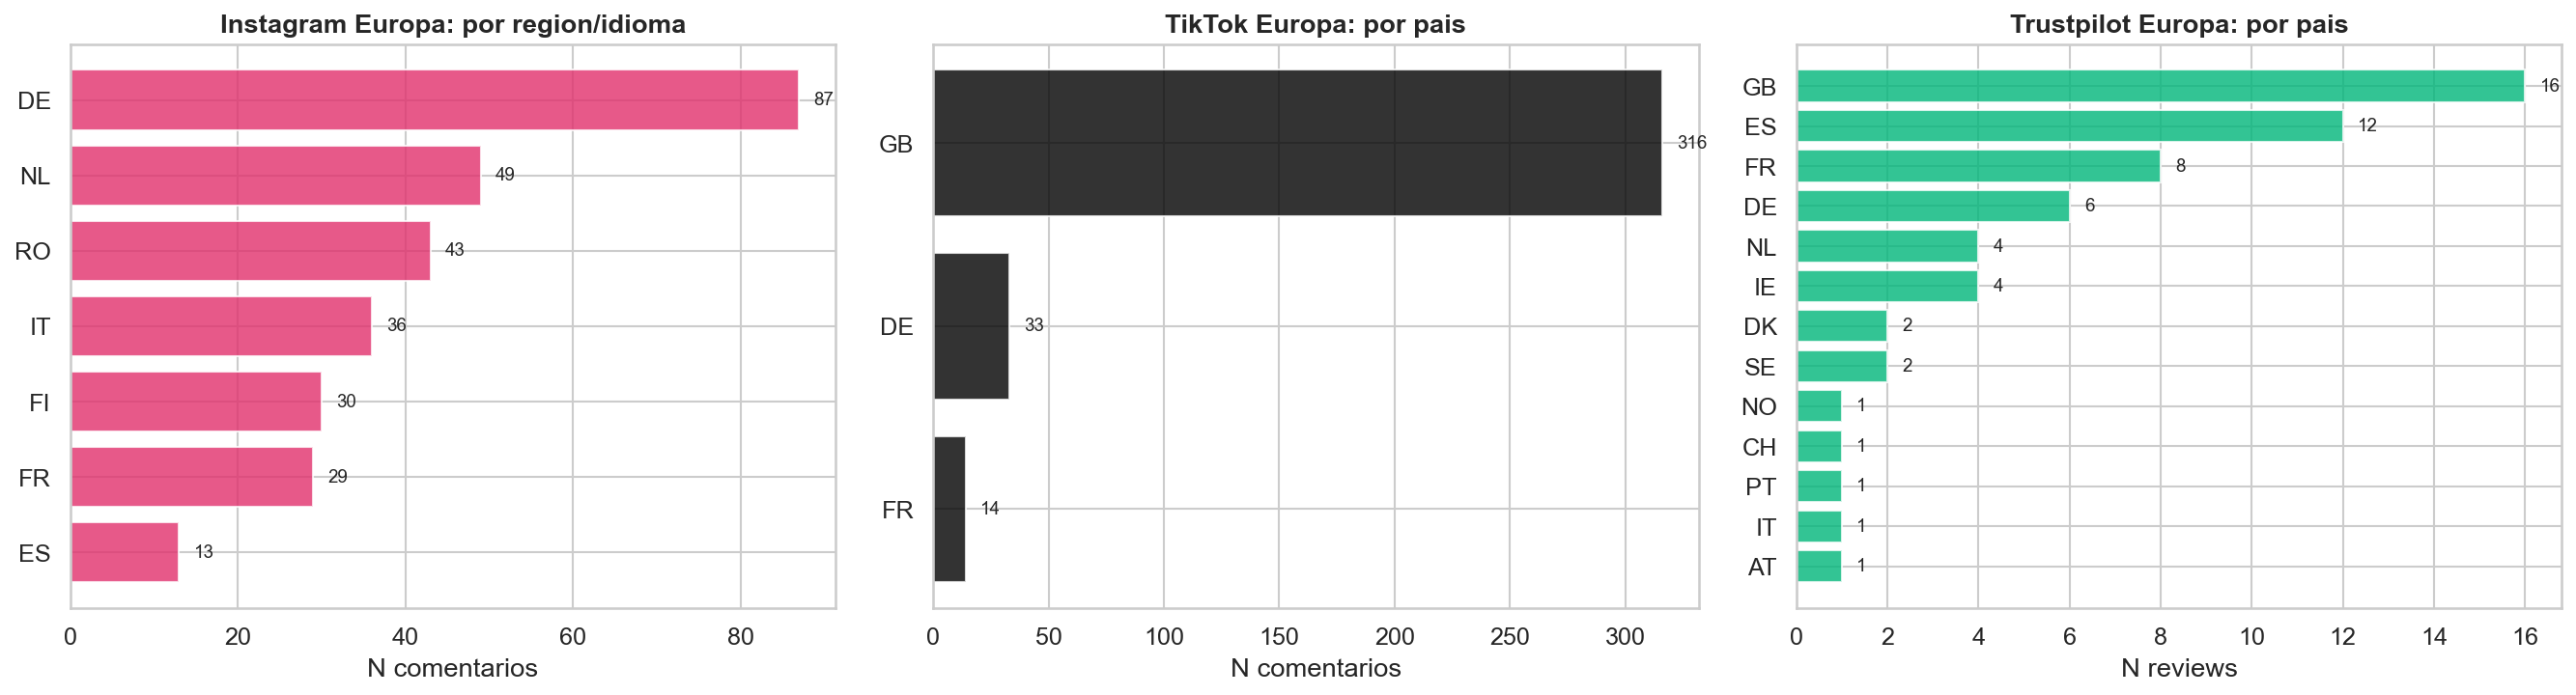

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Instagram Europa - por region (que viene del idioma detectado)
ig_eu = ig_com[ig_com["zone"] == "Europa"]
ig_eu_lang = ig_eu["region"].value_counts()
axes[0].barh(ig_eu_lang.index[::-1], ig_eu_lang.values[::-1], color=C_IG, alpha=0.8)
axes[0].set_title("Instagram Europa: por region/idioma", fontweight="bold")
axes[0].set_xlabel("N comentarios")
for i, v in enumerate(ig_eu_lang.values[::-1]):
    axes[0].text(v + max(ig_eu_lang.values)*0.02, i, f"{v}", va="center", fontsize=9)

# TikTok Europa - por pais de busqueda
tk_eu = tk_com[tk_com["zone"] == "Europa"]
if "pais_busqueda" in tk_eu.columns:
    tk_eu_lang = tk_eu["pais_busqueda"].value_counts()
else:
    tk_eu_lang = tk_eu["region_search"].value_counts()
axes[1].barh(tk_eu_lang.index[::-1], tk_eu_lang.values[::-1], color=C_TK, alpha=0.8)
axes[1].set_title("TikTok Europa: por pais", fontweight="bold")
axes[1].set_xlabel("N comentarios")
for i, v in enumerate(tk_eu_lang.values[::-1]):
    axes[1].text(v + max(tk_eu_lang.values)*0.02, i, f"{v}", va="center", fontsize=9)

# Trustpilot Europa - por pais
tp_eu = tp_lulu[tp_lulu["zone"] == "Europa"]
tp_eu_country = tp_eu["country"].value_counts()
axes[2].barh(tp_eu_country.index[::-1], tp_eu_country.values[::-1], color=C_TP, alpha=0.8)
axes[2].set_title("Trustpilot Europa: por pais", fontweight="bold")
axes[2].set_xlabel("N reviews")
for i, v in enumerate(tp_eu_country.values[::-1]):
    axes[2].text(v + max(tp_eu_country.values)*0.02, i, f"{v}", va="center", fontsize=9)

plt.tight_layout()
save_fig(fig, "eda_europa_idiomas")
plt.show()

**Interpretacion:** El desglose por idioma/pais dentro de Europa revela que mercados europeos estan mas representados. En Instagram el idioma se usa como proxy de region. En Trustpilot el pais es un dato real del reviewer. Mercados como GB y DE suelen tener mas presencia por la popularidad de Lululemon en esos paises.

## 4. Volumetria: entries totales por region y fuente

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/eda_volumetria_raw.png


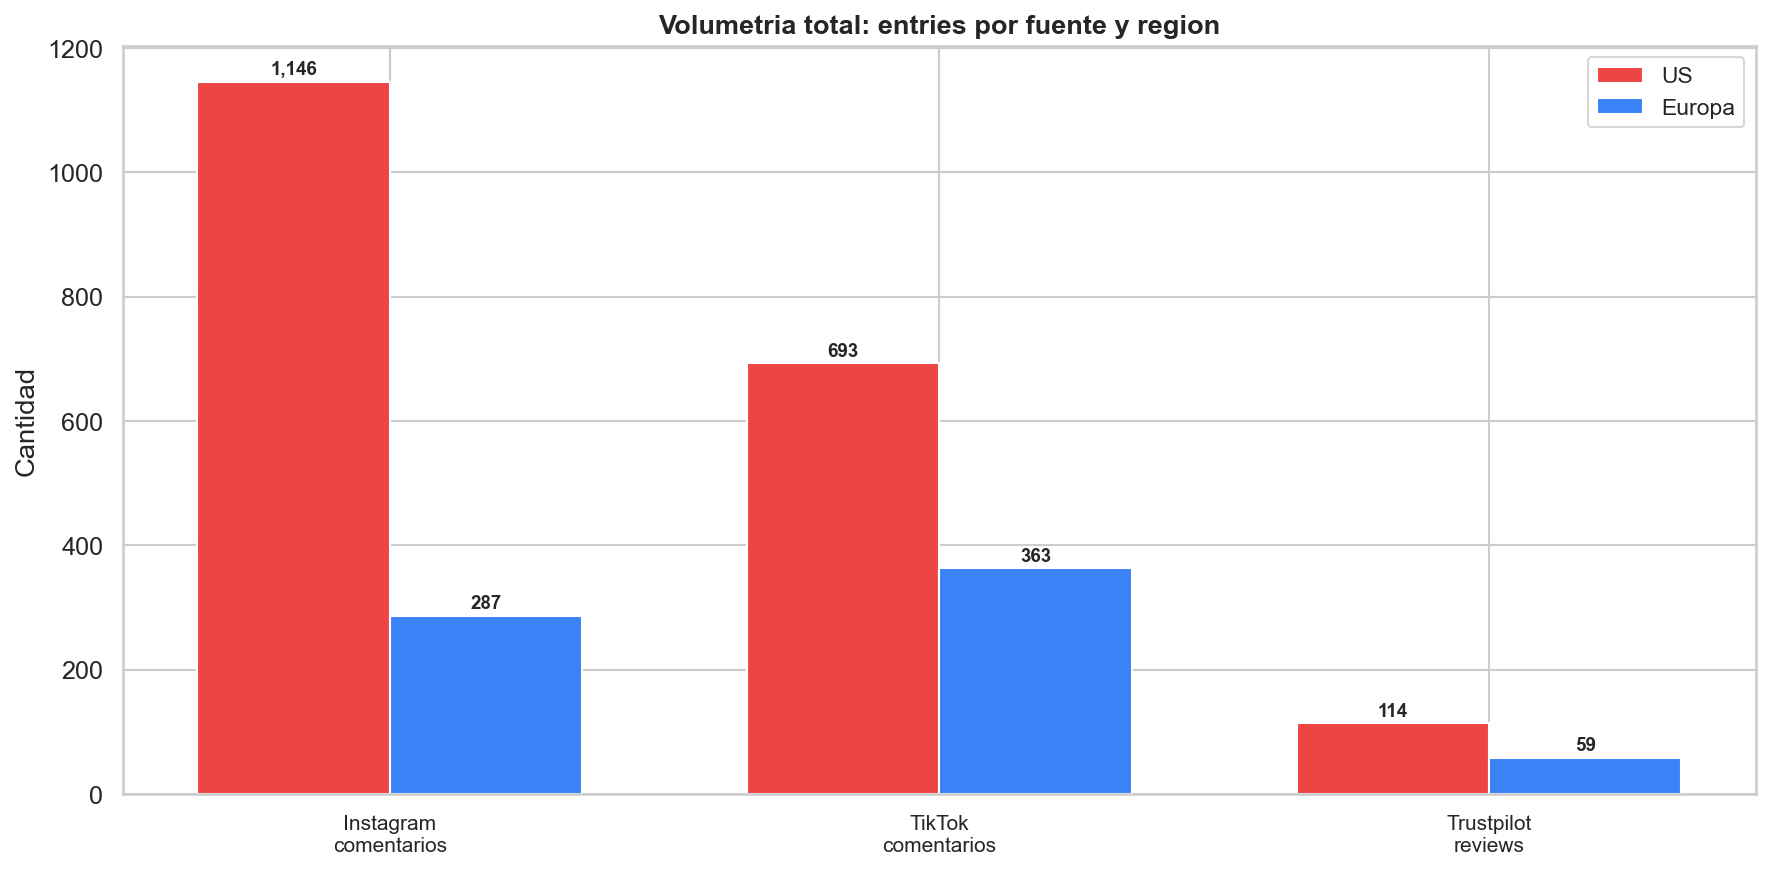

In [50]:
fig, ax = plt.subplots(figsize=(12, 6))

# Construir tabla de volumetria
sources = ["Instagram\ncomentarios", "TikTok\ncomentarios", "Trustpilot\nreviews"]
us_vals = [
    len(ig_com[ig_com["zone"]=="US"]),
    len(tk_com[tk_com["zone"]=="US"]),
    len(tp_lulu[tp_lulu["zone"]=="US"]),
]
eu_vals = [
    len(ig_com[ig_com["zone"]=="Europa"]),
    len(tk_com[tk_com["zone"]=="Europa"]),
    len(tp_lulu[tp_lulu["zone"]=="Europa"]),
]

x = np.arange(len(sources))
width = 0.35

bars_us = ax.bar(x - width/2, us_vals, width, label="US", color="#EF4444")
bars_eu = ax.bar(x + width/2, eu_vals, width, label="Europa", color="#3B82F6")

ax.set_title("Volumetria total: entries por fuente y region", fontweight="bold", fontsize=13)
ax.set_ylabel("Cantidad")
ax.set_xticks(x)
ax.set_xticklabels(sources, fontsize=10)
ax.legend(fontsize=11)

for bar in bars_us:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + max(us_vals+eu_vals)*0.01, f"{int(h):,}", ha="center", fontsize=9, fontweight="bold")
for bar in bars_eu:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + max(us_vals+eu_vals)*0.01, f"{int(h):,}", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
save_fig(fig, "eda_volumetria_raw")
plt.show()

**Interpretacion:** Esta grafica resume el volumen bruto de datos disponibles para el analisis, desglosado por fuente y region. Es clave para interpretar los resultados posteriores: muestras mas pequenas en ciertos segmentos implican menor representatividad estadistica. Las publicaciones de Instagram no tienen desglose regional porque el filtro por zona se aplica solo a nivel de comentarios.

In [51]:
# Tabla resumen de volumetria
resumen = pd.DataFrame({
    "Fuente": ["Instagram comentarios",
               "TikTok comentarios",
               "Trustpilot reviews (Lululemon)"],
    "Total": [len(ig_com), len(tk_com), len(tp_lulu)],
    "US": [len(ig_com[ig_com["zone"]=="US"]),
           len(tk_com[tk_com["zone"]=="US"]),
           len(tp_lulu[tp_lulu["zone"]=="US"])],
    "Europa": [len(ig_com[ig_com["zone"]=="Europa"]),
               len(tk_com[tk_com["zone"]=="Europa"]),
               len(tp_lulu[tp_lulu["zone"]=="Europa"])],
})
resumen.to_csv("../../outputs/tablas/eda_volumetria.csv", index=False)
resumen

,Fuente,Total,US,Europa
0,Instagram comentarios,1433,1146,287
1,TikTok comentarios,1056,693,363
2,Trustpilot reviews (Lululemon),188,114,59


**Interpretacion:** La tabla numerica complementa la grafica anterior con los valores exactos, facilitando la referencia rapida durante el resto del analisis.